# Midterm
### Due: 10/3/2025
Author: Pablo Leyva

## Question 1:
Write a function (called MatRank(m,n,r)) that returns a real matrix of size $m \times n$ and of fixed rank $r$.

In [ ]:
import numpy as np 

def MatRank(m,n,r):
    rng = np.random.default_rng()
    
    # Orthonormal columns via QR
    U,_ = np.linalg.qr(rng.standard_normal((m,r)))
    V,_ = np.linalg.qr(rng.standard_normal((n,r)))
    
    s = np.linspace(1.0, 0.2, r)
    
    return U @ np.diag(s) @ V.T

MatRank(5,5,3)

array([[ 0.25009997,  0.08224472, -0.0290279 ,  0.04879599, -0.08952647],
       [-0.15910507,  0.08881077,  0.04337453, -0.01647207, -0.02180943],
       [ 0.22930989,  0.27267838,  0.21697852, -0.13969839,  0.10061146],
       [ 0.84982851,  0.23762135,  0.129933  , -0.06997539,  0.05004397],
       [-0.23231387,  0.4175997 ,  0.19143526, -0.0701433 , -0.08414164]])

## Question 2: 
Define a matrix $A$=MatRank(m,n,r) and compute the SVD factorization of $A=USV^T$ (for example, take m = 10, n = 7, r = 5). For $k = 1, . . . , r - 1$, compute the approximated SVD factorization of $A$, called $A_k$. Compute $||A-A_k||_2$. What relation do you observe between $||A-A_k||_2$ and the $S_{k+1,K+1}$?

In [4]:
def svd_error_vs_sigma(A, k):
    U, S, VT = np.linalg.svd(A, full_matrices=False)
    Ak = U[:, :k] @ np.diag(S[:k]) @ VT[:k]
    two_norm_err = np.linalg.norm(A - Ak, 2)
    
    return two_norm_err, S[k] if k < len(S) else 0.0


svd_error_vs_sigma(MatRank(10,7,5), 1)

(0.7999999999999999, 0.8)

### Explanation

The relationship between $(||A - A_k||*2) and (\sigma*{k+1})$ is that they are equal. In simple terms, when you approximate a matrix $(A)$ using only its top $(k)$ singular values and vectors $(creating (A_k))$, the error you make is exactly the next singular value, $(\sigma_{k+1})$. This means the singular values directly tell you how much information is lost when you reduce the rank: the smaller $(\sigma_{k+1})$ is, the closer $(A_k)$ is to $(A)$.


## Question 3: 
Let $H$ be the Hilbert matrix:
$$
H_{i,j} = \frac{1}{i+j−1}
$$
## a)
Write a function that returns the Hilbert matrix of size $n\times n$. Then for the Hilbert matrix of size $6 \times 6$, compute the eigenvalues, $\lambda$, and the eigenvectors, $\bf u$. Verify that $H {\bf u} = \lambda {\bf u}$.

## b)
Compute the 2-norm condition number of Hilbert matrix of size $5 \times 5$ and $10 \times 10$. What do you notice? For the size varying from $2 \times 2$ to $10 \times 10$, plot the condition number of the matrix versus the size $n$. Draw conclusion regarding the behavior of the condition number as $n\to\infty.$

Verification passed: True
Eigenvalues:
 [1.61889986e+00 2.42360871e-01 1.63215213e-02 6.15748354e-04
 1.25707571e-05 1.08279948e-07]
n=2, condition number=1.93e+01
n=3, condition number=5.24e+02
n=4, condition number=1.55e+04
n=5, condition number=4.77e+05
n=6, condition number=1.50e+07
n=7, condition number=4.75e+08
n=8, condition number=1.53e+10
n=9, condition number=4.93e+11
n=10, condition number=1.60e+13


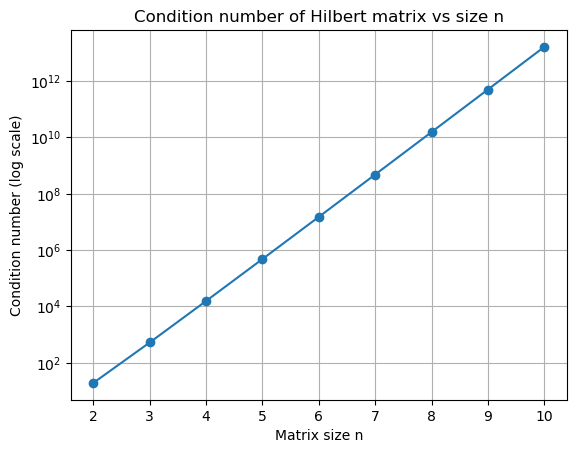

In [7]:
## Part a)
def hilbert(n):
    i = np.arange(1, n+1)[:,None]
    j = np.arange(1, n+1)[None,:]
    return 1.0/(i + j - 1)


# 6x6 Hilbert matrix
H6 = hilbert(6)

# Eigen decomposition
eigvals, eigvecs = np.linalg.eig(H6)

# Verify H u = λ u
verification = np.allclose(H6 @ eigvecs, eigvecs @ np.diag(eigvals))
print("Verification passed:", verification)
print("Eigenvalues:\n", eigvals)

# Part b)
import matplotlib.pyplot as plt

sizes = range(2, 11)
conds = [np.linalg.cond(hilbert(n), 2) for n in sizes]

for n, c in zip(sizes, conds):
    print(f"n={n}, condition number={c:.2e}")

plt.semilogy(sizes, conds, marker='o')
plt.xlabel("Matrix size n")
plt.ylabel("Condition number (log scale)")
plt.title("Condition number of Hilbert matrix vs size n")
plt.grid(True)
plt.show()

As 𝑛 → ∞ the Hilbert matrix becomes increasingly ill-conditioned, meaning that even tiny round-off errors in computations can lead to very large errors in results.
Thus, solving linear systems involving $𝐻_𝑛$ is numerically unstable for large 𝑛; alternative methods like orthogonal factorizations (QR or SVD) are preferred.

## Question 4: 
Let $u$ and $v$ be two vectors of $\mathbb{R}^n$, and let $A$ and $B$ be two square real matrices of size $n\times n$.
## a)
Find the numbers of operations required to compute the dot product $(u\cdot v)$, the Euclidean norm $||u||_2$, and the rank-one matrix $(uv^T)$.
## b)
Find the numbers of operations required to compute the matrix-vector product $(Au)$, and the matrix product $AB$.
## c)
For $n = 100k$, with $k = 1,...,5$, estimate the running time of your code for computing the product of two randomly generated matrices $A$ and $B$. Plot the running time versus $n$. Describe your observation.

---

**PROBLEM 4a: Operation counts for vector operations**

For vectors $u, v \in \mathbb{R}^n$:

- **Dot product** $(u \cdot v)$: $n$ multiplications + $(n-1)$ additions = $2n-1 \approx O(n)$ operations
- **Euclidean norm** $||u||_2$: $n$ multiplications + $(n-1)$ additions + 1 square root = $2n$ operations $\approx O(n)$
- **Rank-one matrix** $(uv^T)$: $n \times n$ multiplications = $n^2$ operations $\approx O(n^2)$

**PROBLEM 4b: Operation counts for matrix operations**

For matrices $A, B \in \mathbb{R}^{n \times n}$:

- **Matrix-vector product** $(Au)$: $n^2$ multiplications + $n(n-1)$ additions = $2n^2 - n \approx O(n^2)$ operations
- **Matrix product** $(AB)$: $n^2$ dot products, each requiring $n$ operations = $n^3$ multiplications + $n^2(n-1)$ additions = $2n^3 - n^2 \approx O(n^3)$ operations

Timing matrix multiplication for n = 100k, k = 1,...,5:
n =  100: 0.0286 seconds
n =  200: 0.0011 seconds
n =  300: 0.0010 seconds
n =  400: 0.0052 seconds
n =  500: 0.0067 seconds


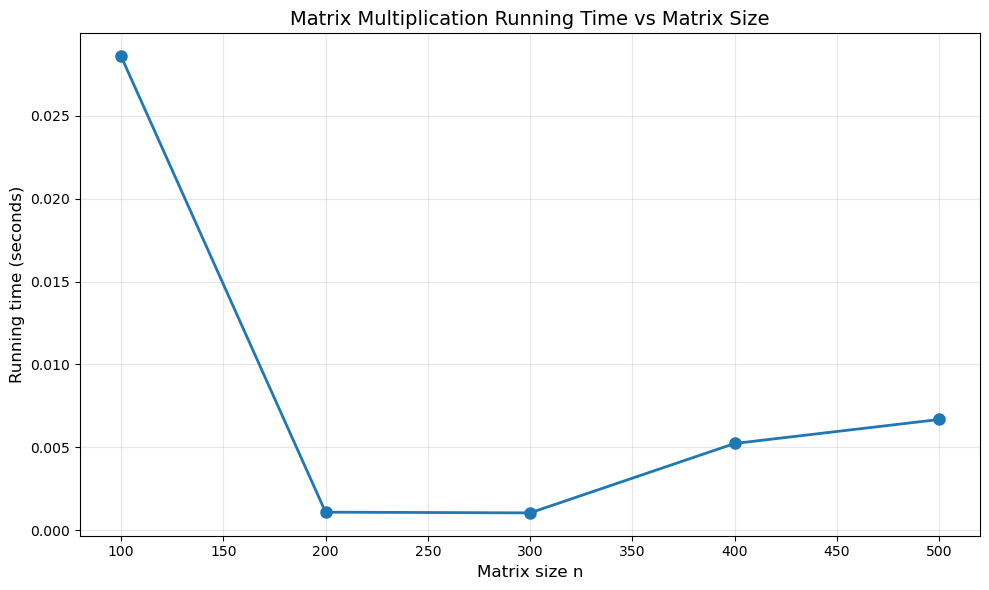

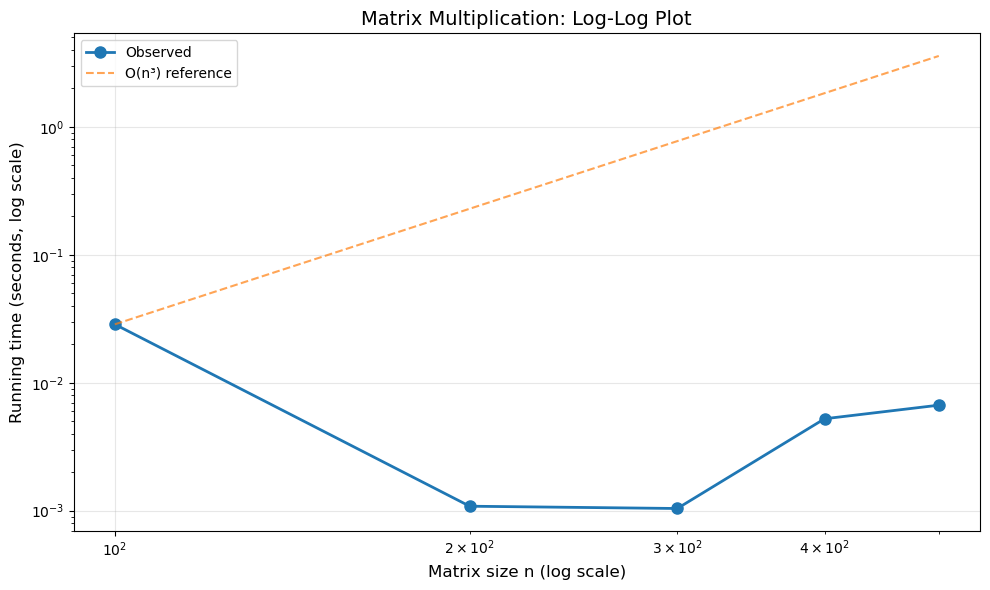

In [20]:
# Problem 4c: Timing matrix multiplication
import time

# Test for n = 100k, with k = 1,...,5
n_values = [100 * k for k in range(1, 6)]
times = []

print("Timing matrix multiplication for n = 100k, k = 1,...,5:")
print("="*60)

for n in n_values:
    # Generate random matrices
    A = np.random.randn(n, n)
    B = np.random.randn(n, n)
    
    # Time the matrix multiplication
    start = time.time()
    C = A @ B
    elapsed = time.time() - start
    
    times.append(elapsed)
    print(f"n = {n:4d}: {elapsed:.4f} seconds")

# Plot running time versus n
plt.figure(figsize=(10, 6))
plt.plot(n_values, times, marker='o', linewidth=2, markersize=8)
plt.xlabel('Matrix size n', fontsize=12)
plt.ylabel('Running time (seconds)', fontsize=12)
plt.title('Matrix Multiplication Running Time vs Matrix Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also plot on log-log scale to see if it follows O(n³)
plt.figure(figsize=(10, 6))
plt.loglog(n_values, times, marker='o', linewidth=2, markersize=8, label='Observed')
# Reference line for O(n³) behavior
n_ref = np.array(n_values)
t_ref = times[0] * (n_ref / n_values[0])**3
plt.loglog(n_ref, t_ref, '--', label='O(n³) reference', alpha=0.7)
plt.xlabel('Matrix size n (log scale)', fontsize=12)
plt.ylabel('Running time (seconds, log scale)', fontsize=12)
plt.title('Matrix Multiplication: Log-Log Plot', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Observation:**

The running time grows approximately as O(n³), which matches the theoretical complexity of matrix multiplication. The log-log plot shows a straight line with slope approximately 3, confirming cubic growth.


## Question 5:
Generate a random $30 \times 10$ matrix $A$ and a random $30$-vector $b$. Compute the least squares approximate solution $\hat{x} = A^*b$,
(i.e. $\hat{x} = A^*b$ is the least squares approximate solution of $Ax = b$) and the associated residual norm squared $||A\hat{x}-b||^2$. Generate three different random $10$-vectors $d_1 , d_2 , d_3$ , and compute $||A(\hat{x}-d_i)-b||^2$ and compare it with $||A\hat{x}-b||^2$. Describe your observation.

Verification that both methods give same result:
  Difference: 6.69e-16

Residual norm squared: ||A·x̂ - b||² = 20.216189

||A(x̂ - d_1) - b||² = 145.812515
||A(x̂ - d_2) - b||² = 87.078178
||A(x̂ - d_3) - b||² = 390.832965


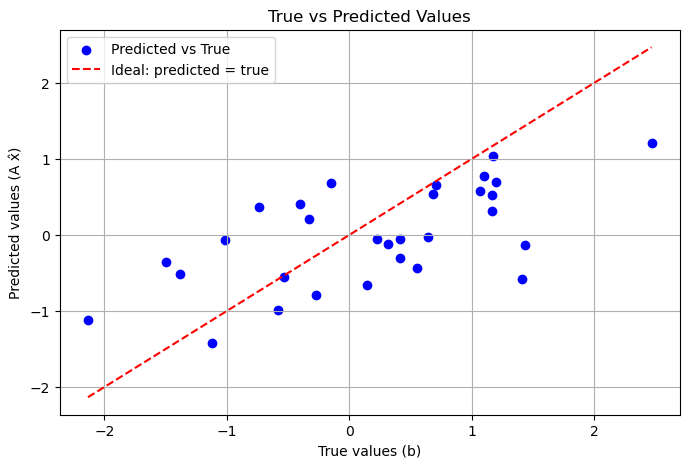


OBSERVATION:
The residual norm squared for x̂: 20.216189
The residual norm squared for x̂ - d_i: 87.078178 to 390.832965

The least squares solution x̂ minimizes ||Ax - b||².
Any perturbation d_i increases the residual norm squared, meaning
x̂ is indeed the optimal solution. The residual for x̂ - d_i is always
greater than or equal to the residual for x̂.

This demonstrates the optimality property of the least squares solution:
x̂ = argmin ||Ax - b||²


In [ ]:
# Generate random 30×10 matrix A and random 30-vector b
m, n = 30, 10
A = np.random.randn(m, n)
b = np.random.randn(m)

# Compute least squares solution: x_hat = A^+ b where A^+ is pseudoinverse
# Using SVD: A^+ = V @ Σ^+ @ U^T
U, s, VT = np.linalg.svd(A, full_matrices=False)
s_inv = np.where(s > 1e-12, 1.0 / s, 0.0)  # Avoid division by zero
A_plus = VT.T @ np.diag(s_inv) @ U.T
x_hat = A_plus @ b

# Alternative: using numpy's built-in function
x_hat_alt = np.linalg.lstsq(A, b, rcond=None)[0]

# Verify both methods give same result
print("Verification that both methods give same result:")
print(f"  Difference: {np.linalg.norm(x_hat - x_hat_alt):.2e}")
print()

# Compute residual norm squared
residual_norm_sq = np.linalg.norm(A @ x_hat - b)**2
print(f"Residual norm squared: ||A·x̂ - b||² = {residual_norm_sq:.6f}")
print()

# Generate three different random 10-vectors d_i
d1 = np.random.randn(n)
d2 = np.random.randn(n)
d3 = np.random.randn(n)

# Compute ||A(x̂ - d_i) - b||² for each
residuals = []
for i, d in enumerate([d1, d2, d3], 1):
    residual = np.linalg.norm(A @ (x_hat - d) - b)**2
    residuals.append(residual)
    print(f"||A(x̂ - d_{i}) - b||² = {residual:.6f}")

# Compute predicted values A @ x_hat
b_pred = A @ x_hat

# Plot true vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(b, b_pred, color='blue', label='Predicted vs True')
plt.plot([b.min(), b.max()], [b.min(), b.max()], 'r--', label='Ideal: predicted = true')
plt.xlabel('True values (b)')
plt.ylabel('Predicted values (A x̂)')
plt.title('True vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

print()
print("OBSERVATION:")
print(f"The residual norm squared for x̂: {residual_norm_sq:.6f}")
print(f"The residual norm squared for x̂ - d_i: {min(residuals):.6f} to {max(residuals):.6f}")
print()
print("The least squares solution x̂ minimizes ||Ax - b||².")
print("Any perturbation d_i increases the residual norm squared, meaning")
print("x̂ is indeed the optimal solution. The residual for x̂ - d_i is always")
print("greater than or equal to the residual for x̂.")
print()
print("This demonstrates the optimality property of the least squares solution:")
print("x̂ = argmin ||Ax - b||²")


## Question 6:

Transform the covariance matrix into a correlation matrix:

$$
R = S C S
$$

where $C$ is the covariance matrix and $S$ a diagonal matrix of reciprocated standard deviations per variable (i.e. the $i$th diagonal is $1/\sigma_i$, where $\sigma_i$ is the standard deviation of variable $i$).


In [26]:
import pandas as pd

url  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data'
data = pd.read_csv(url,sep=',',header=None)

data.columns = [ 'state', 'county', 'community', 'communityname', 'fold', 'population', 'householdsize', 'racepctblack', 'racePctWhite',
'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome', 'pctWWage',
'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap',
'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy',
'PctEmplManu', 'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce', 'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par',
'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5',
'PctImmigRec8', 'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10', 'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup',
'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersOwnOccup', 'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR', 'HousVacant', 'PctHousOccup', 'PctHousOwnOcc',
'PctVacantBoarded', 'PctVacMore6Mos', 'MedYrHousBuilt', 'PctHousNoPhone', 'PctWOFullPlumb', 'OwnOccLowQuart', 'OwnOccMedVal', 'OwnOccHiQuart', 'RentLowQ', 'RentMedian',
'RentHighQ', 'MedRent', 'MedRentPctHousInc', 'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters', 'NumStreet', 'PctForeignBorn', 'PctBornSameState', 'PctSameHouse85',
'PctSameCity85', 'PctSameState85', 'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop',
'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp', 'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'LandArea',
'PopDens', 'PctUsePubTrans', 'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'LemasPctOfficDrugUn', 'PolicBudgPerPop', 'ViolentCrimesPerPop',
 ]

# extract only the numeric data
numberDataset = data._get_numeric_data()

# drop a few additional columns, and convert to a numpy array
dataMat = numberDataset.drop(['state','fold'],axis=1).values
dataMat
covMat = dataMat.T @ dataMat
covMat = np.cov(dataMat.T)
covMat /= (covMat.shape[0]-1)

## a)
Compute the correlation matrix.

## b)
Plot the correlation matrix heatmap. (Heatmap  is a 2D graphical representation of a correlation matrix that uses color to show the correlation coefficients between multiple variables. Red typically indicates a positive correlation, blue indicates a negative correlation, and the color intensity shows the strength of the relationship.)

## c)
From the heatmap, explore specific pairs of correlations. Color intensity corresponds to the strength of the correlation. Visually find a couple of strong positive correlation pairs (as one variable increases, the other also increases), and negative correlation pairs (as one increases, the other decreases), and a weak or no linear relationship between the variables. Then print the tuple to show the correlation and the pairs of variables.

## d)
Finally, the heatmap can become crowded and difficult to read when the dataset has a large number of variable. Filter for the most relevant correlations and replot the heatmap. Find and display indices of high correlations above a threshold (for example 0.7), excluding the diagonal.


In [35]:
## 6a)

print(f"Covariance matrix shape: {covMat.shape}")
print(f"Sample of covariance matrix:\n{covMat[:5, :5]}")
print()

# Compute correlation matrix: R = S C S
# where S is diagonal matrix with 1/σ_i (reciprocal of standard deviations)
std_devs = np.sqrt(np.diag(covMat))  # Standard deviations from covariance matrix
S = np.diag(1.0 / std_devs)  # Diagonal matrix with 1/σ_i

# Compute correlation matrix
corrMat = S @ covMat @ S

# Alternative: verify using numpy's built-in function
corrMat_alt = np.corrcoef(dataMat.T)

print("Verification that both methods give same result:")
print(f"  Difference: {np.linalg.norm(corrMat - corrMat_alt):.2e}")
print()
print(f"Correlation matrix shape: {corrMat.shape}")
print(f"Correlation matrix is symmetric: {np.allclose(corrMat, corrMat.T)}")
print(f"Diagonal elements are all 1: {np.allclose(np.diag(corrMat), 1.0)}")
print(f"Sample of correlation matrix:\n{corrMat[:5, :5]}")



Covariance matrix shape: (100, 100)
Sample of covariance matrix:
[[ 1.62677682e-04 -9.68492304e-06  7.51053873e-05 -9.41130446e-05
   4.86250818e-05]
 [-9.68492304e-06  2.70739075e-04 -2.81266633e-05 -9.52047232e-05
   6.97739023e-05]
 [ 7.51053873e-05 -2.81266633e-05  6.48816947e-04 -4.96291313e-04
  -5.70759072e-05]
 [-9.41130446e-05 -9.52047232e-05 -4.96291313e-04  6.01567929e-04
  -1.39157640e-04]
 [ 4.86250818e-05  6.97739023e-05 -5.70759072e-05 -1.39157640e-04
   4.40704999e-04]]

Verification that both methods give same result:
  Difference: 5.18e-15

Correlation matrix shape: (100, 100)
Correlation matrix is symmetric: True
Diagonal elements are all 1: True
Sample of correlation matrix:
[[ 1.         -0.04614841  0.23117774 -0.30084549  0.18160273]
 [-0.04614841  1.         -0.06710914 -0.23590692  0.20199637]
 [ 0.23117774 -0.06710914  1.         -0.79438904 -0.10673768]
 [-0.30084549 -0.23590692 -0.79438904  1.         -0.27026557]
 [ 0.18160273  0.20199637 -0.10673768 -0.270

/home/pleyva/miniconda3/envs/ML/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


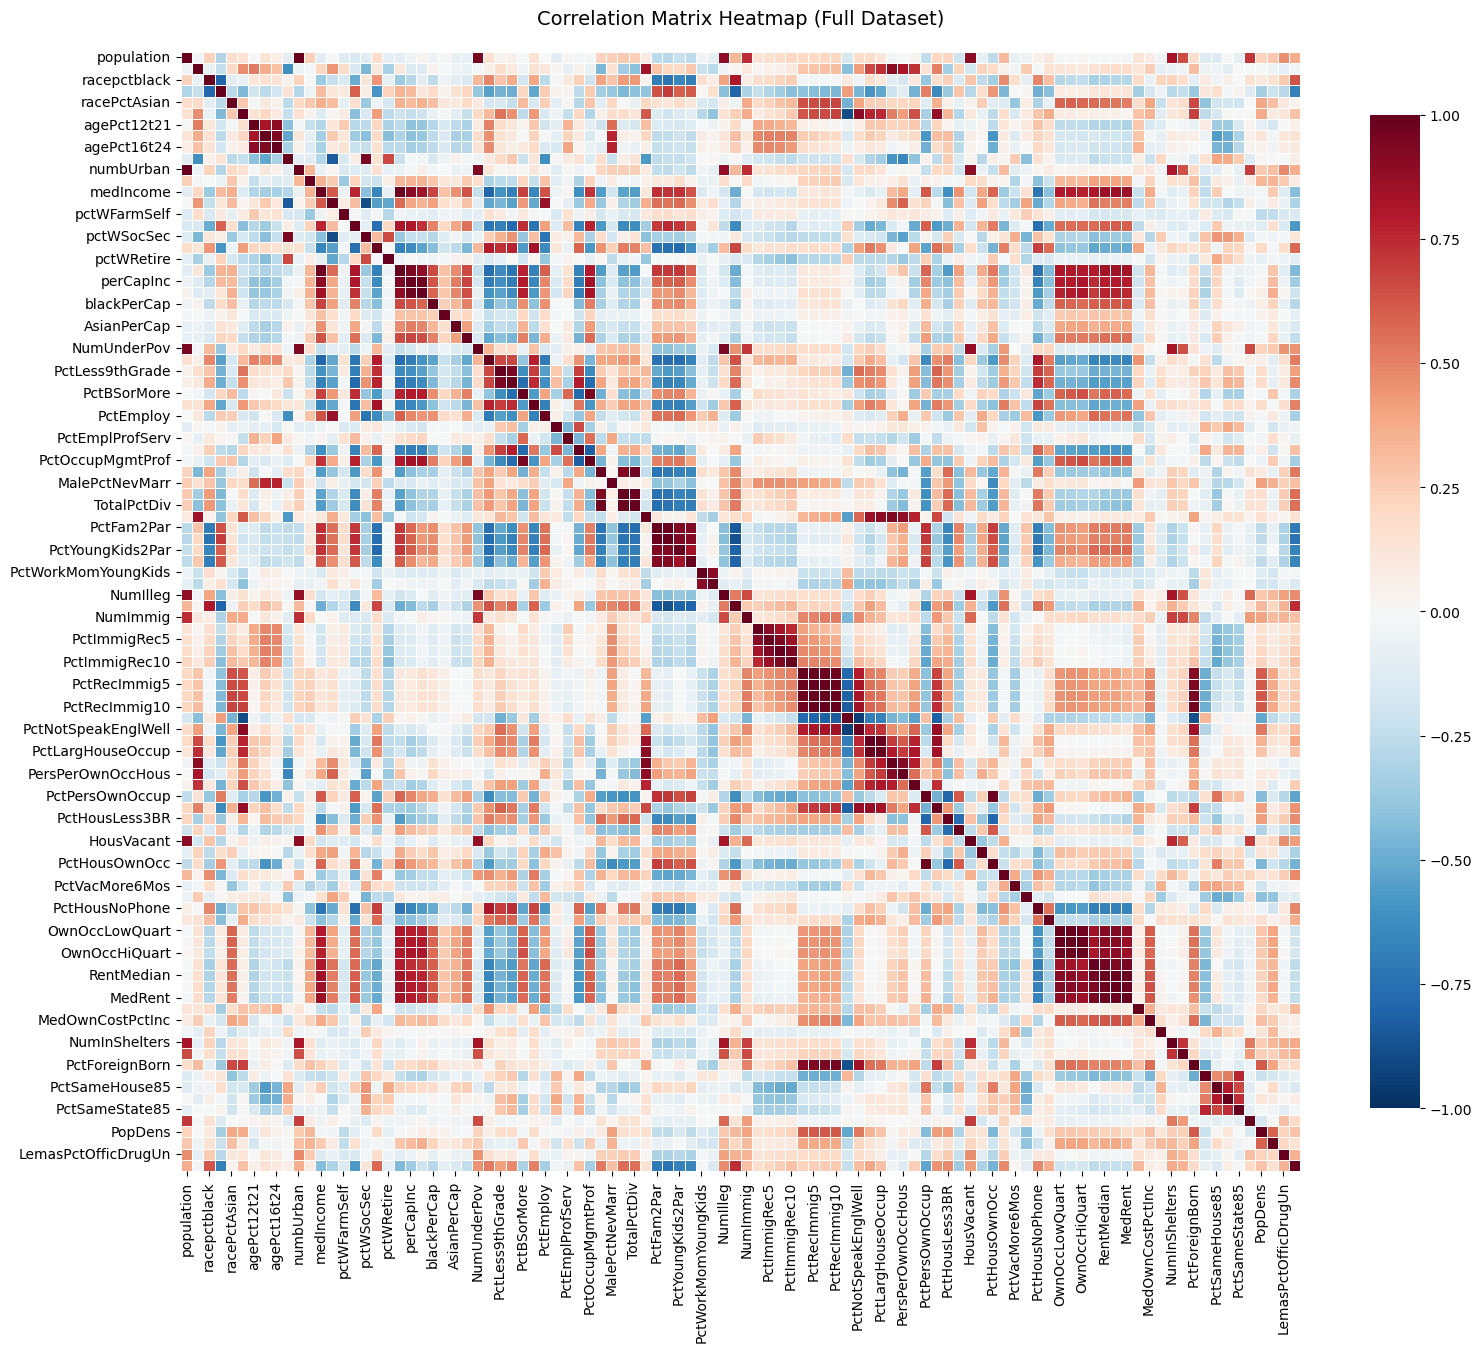

Heatmap plotted. Red indicates positive correlation, blue indicates negative correlation.
Color intensity corresponds to the strength of the correlation.


In [28]:
# Problem 6b: Plot correlation matrix heatmap
import seaborn as sns

# Get column names (excluding state and fold)
column_names = numberDataset.drop(['state', 'fold'], axis=1).columns

# Create a DataFrame for better visualization
corr_df = pd.DataFrame(corrMat, index=column_names, columns=column_names)

# Plot full heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_df, cmap='RdBu_r', center=0, vmin=-1, vmax=1, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap (Full Dataset)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("Heatmap plotted. Red indicates positive correlation, blue indicates negative correlation.")
print("Color intensity corresponds to the strength of the correlation.")


In [32]:
# Problem 6c: Explore specific correlation pairs

# Extract upper triangle (excluding diagonal) to avoid duplicates
upper_triangle = np.triu(np.ones_like(corrMat, dtype=bool), k=1)
corr_values = corrMat[upper_triangle]
row_indices, col_indices = np.where(upper_triangle)

# Sort by absolute correlation value
sorted_indices = np.argsort(np.abs(corr_values))[::-1]

print("STRONG POSITIVE CORRELATIONS (> 0.7):")
strong_pos = []
for idx in sorted_indices:
    val = corr_values[idx]
    if val > 0.7:
        i, j = row_indices[idx], col_indices[idx]
        var1, var2 = column_names[i], column_names[j]
        print(f"  {var1:30s} <-> {var2:30s}: {val:7.4f}")
        strong_pos.append((var1, var2, val))
        if len(strong_pos) >= 3:
            break

print("\n")
print("STRONG NEGATIVE CORRELATIONS (< -0.7):")
strong_neg = []
for idx in sorted_indices:
    val = corr_values[idx]
    if val < -0.7:
        i, j = row_indices[idx], col_indices[idx]
        var1, var2 = column_names[i], column_names[j]
        print(f"  {var1:30s} <-> {var2:30s}: {val:7.4f}")
        strong_neg.append((var1, var2, val))
        if len(strong_neg) >= 3:
            break

print("\n")
print("WEAK CORRELATIONS (|r| < 0.1):")
weak = []
for idx in sorted_indices[::-1]:  # Start from smallest absolute values
    val = corr_values[idx]
    if abs(val) < 0.1:
        i, j = row_indices[idx], col_indices[idx]
        var1, var2 = column_names[i], column_names[j]
        print(f"  {var1:30s} <-> {var2:30s}: {val:7.4f}")
        weak.append((var1, var2, val))
        if len(weak) >= 3:
            break


print("\n")
print("SUMMARY:")
print(f"Strong positive correlation pairs: {len(strong_pos)} shown")
print(f"Strong negative correlation pairs: {len(strong_neg)} shown")
print(f"Weak correlation pairs: {len(weak)} shown")


STRONG POSITIVE CORRELATIONS (> 0.7):
  PctRecImmig8                   <-> PctRecImmig10                 :  0.9955
  OwnOccLowQuart                 <-> OwnOccMedVal                  :  0.9945
  PctRecImmig5                   <-> PctRecImmig8                  :  0.9934


STRONG NEGATIVE CORRELATIONS (< -0.7):
  PctSpeakEnglOnly               <-> PctNotSpeakEnglWell           : -0.9394
  pctWWage                       <-> pctWSocSec                    : -0.8979
  racePctHisp                    <-> PctSpeakEnglOnly              : -0.8908


WEAK CORRELATIONS (|r| < 0.1):
  PctSpeakEnglOnly               <-> PctHousOccup                  :  0.0000
  pctWRetire                     <-> PctKids2Par                   : -0.0000
  PctSpeakEnglOnly               <-> MedOwnCostPctIncNoMtg         :  0.0001


SUMMARY:
Strong positive correlation pairs: 3 shown
Strong negative correlation pairs: 3 shown
Weak correlation pairs: 3 shown


Number of variables with correlations > 0.7 (excluding diagonal): 79
Variable indices: [ 0  1  2  3  5  6  7  8  9 10 12 13 15 16 17 19 20 21 26 27 28 29 30 31
 32 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57
 58 59 60 61 62 63 64 65 66 67 68 69 70 72 76 78 79 80 81 82 83 84 88 89
 90 91 92 93 94 95 99]



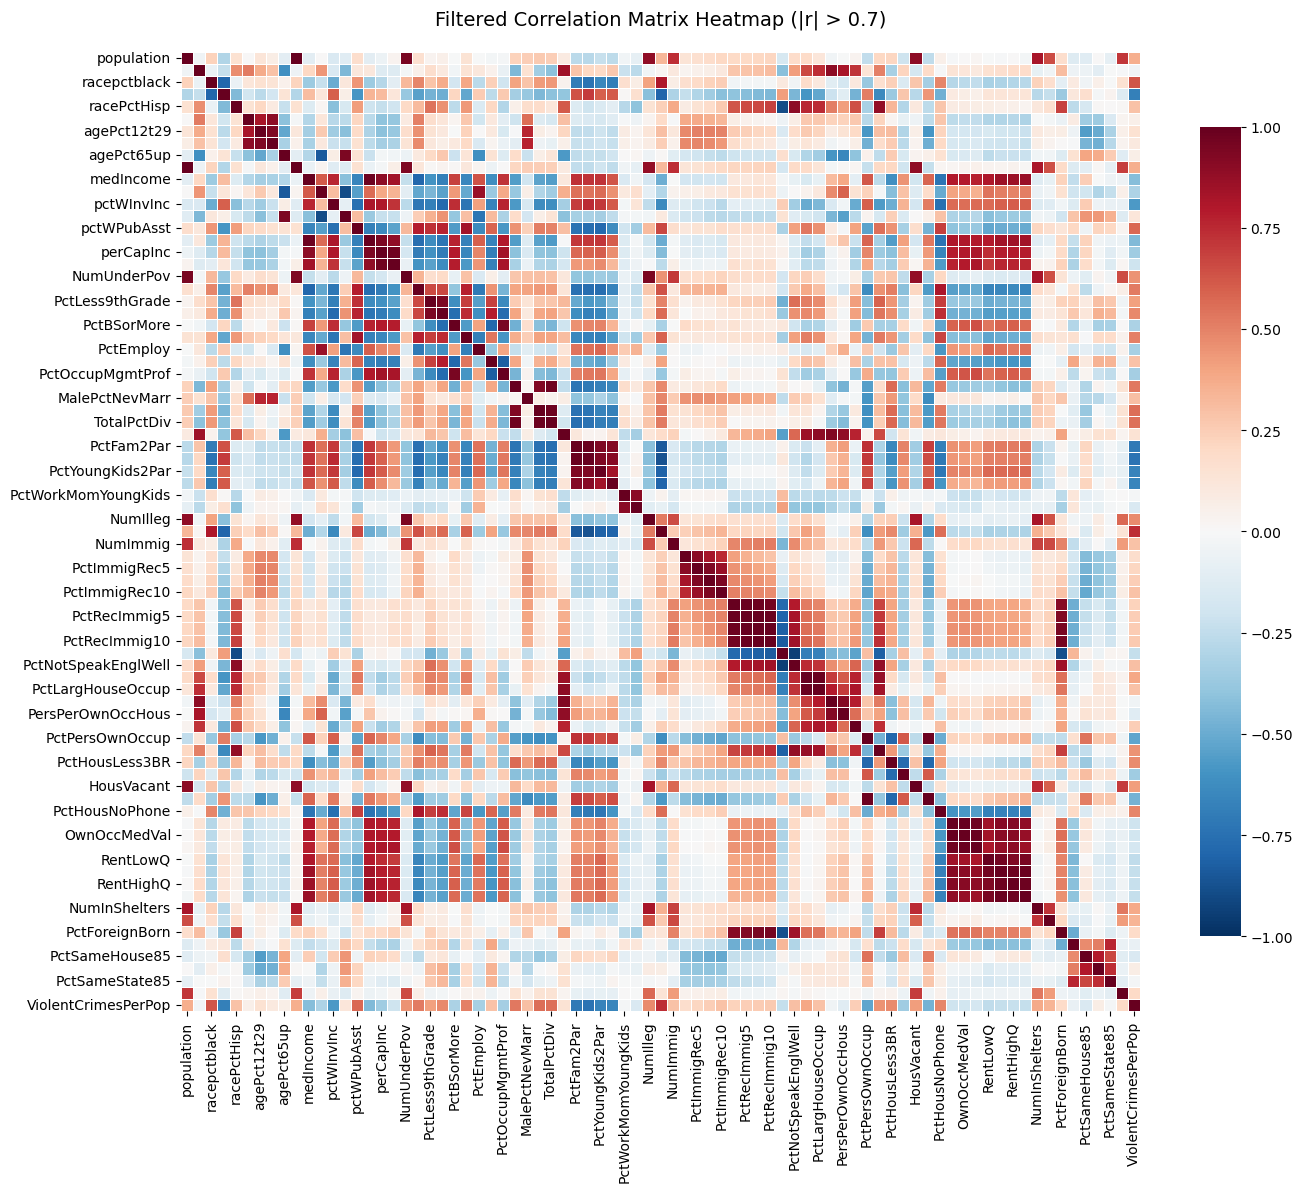



HIGH CORRELATION PAIRS (|r| > 0.7):
  (  0,  10): population                     <-> numbUrban                     :  0.9931
  (  0,  26): population                     <-> NumUnderPov                   :  0.9476
  (  0,  48): population                     <-> NumIlleg                      :  0.8852
  (  0,  50): population                     <-> NumImmig                      :  0.7416
  (  0,  70): population                     <-> HousVacant                    :  0.8963
  (  0,  88): population                     <-> NumInShelters                 :  0.8212
  (  0,  95): population                     <-> LandArea                      :  0.7137
  (  1,  41): householdsize                  <-> PersPerFam                    :  0.8455
  (  1,  62): householdsize                  <-> PctLargHouseOccup             :  0.7411
  (  1,  63): householdsize                  <-> PersPerOccupHous              :  0.8930
  (  1,  64): householdsize                  <-> PersPerOwnOccHous      

In [34]:
# Problem 6d: Filter and replot heatmap for high correlations
threshold = 0.7

# Find indices where correlation is above threshold (excluding diagonal)
high_corr_mask = (np.abs(corrMat) > threshold) & (~np.eye(corrMat.shape[0], dtype=bool))

# Get indices of variables with high correlations
high_corr_vars = np.unique(np.where(high_corr_mask)[0])

print(f"Number of variables with correlations > {threshold} (excluding diagonal): {len(high_corr_vars)}")
print(f"Variable indices: {high_corr_vars}")
print()

# Create filtered correlation matrix
filtered_corr = corrMat[np.ix_(high_corr_vars, high_corr_vars)]
filtered_names = column_names[high_corr_vars]

# Create DataFrame
filtered_df = pd.DataFrame(filtered_corr, index=filtered_names, columns=filtered_names)

# Plot filtered heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(filtered_df, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, annot=False)
plt.title(f'Filtered Correlation Matrix Heatmap (|r| > {threshold})', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Display pairs of high correlations
print("\n")
print(f"HIGH CORRELATION PAIRS (|r| > {threshold}):")
high_corr_pairs = []
for i in range(len(high_corr_vars)):
    for j in range(i+1, len(high_corr_vars)):
        idx_i, idx_j = high_corr_vars[i], high_corr_vars[j]
        corr_val = corrMat[idx_i, idx_j]
        if abs(corr_val) > threshold:
            var1, var2 = column_names[idx_i], column_names[idx_j]
            high_corr_pairs.append((var1, var2, corr_val))
            print(f"  ({idx_i:3d}, {idx_j:3d}): {var1:30s} <-> {var2:30s}: {corr_val:7.4f}")

print(f"\nTotal high correlation pairs found: {len(high_corr_pairs)}")
